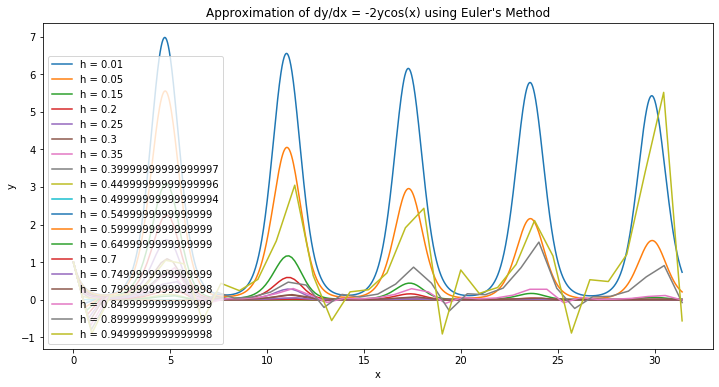

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
h_values = [0.01, 0.05, 0.15, 0.20] + list(np.arange(0.25, 1.00, 0.05))  # step size
x_start, x_end = 0, 10*np.pi

avg_y_values = []

# Store all runs
solutions = {}


# Function representing dy/dx = -2y * cos(x)
def f(x, y):
    return -2 * y * np.cos(x)


def euler_method(h, x0, x_end, y0, f):
    
    x_start, x_end = 0, 10*np.pi
    
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    
    y_values[0] = y0
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])
        
    return x_values, y_values
    
    
plt.figure(figsize = (12,6))
for h in h_values:
    x, y = euler_method(h,0, 10*np.pi, 1, f)
    plt.plot(x,y, label = f"h = {h}")
    
    solutions[h] = (x, y)
    
    avg_y = np.mean(y)
    avg_y_values.append(avg_y)



# Plot the results
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2ycos(x) using Euler's Method")
plt.legend()
plt.show()

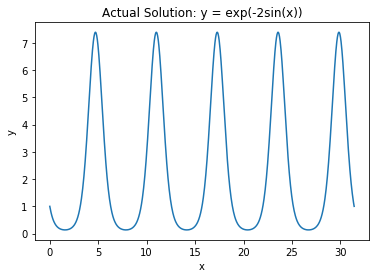

In [4]:
#Actual solution
test = np.linspace(0, 10*np.pi, 1000)
plt.plot(test, np.exp(-2 * np.sin(test)))
plt.xlabel('x')
plt.ylabel('y')
plt.title("Actual Solution: y = exp(-2sin(x))")
plt.show()

In [6]:
def y_exact(x):
    return np.exp(-2 * np.sin(x))

avg_errors = []
local_errors = []

for h in h_values:
    x, y = solutions[h]

    # Exact values at same grid points
    y_true = y_exact(x)

    # Average error over the run
    avg_err = np.mean(np.abs(y - y_true))
    avg_errors.append(avg_err)

    # Local error at x ≈ 15
    idx = np.argmin(np.abs(x - 15))  #asked ChatGPT bc i could not get it to work myself, basically it finds the argument with the smallest difference between 15
    local_err = abs(y[idx] - y_exact(x[idx])) #then calculates error
    local_errors.append(local_err)

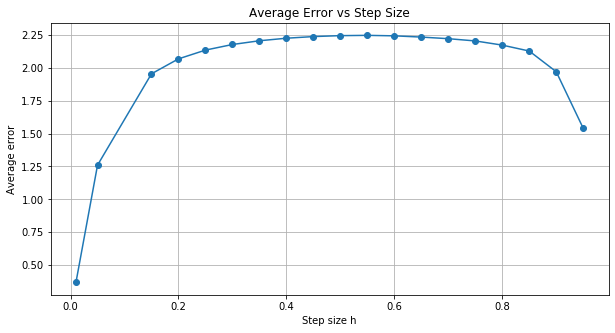

In [7]:
#Plot the avg errors vs h values

plt.figure(figsize=(10, 5))
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel('Step size h')
plt.ylabel('Average error')
plt.title('Average Error vs Step Size')
plt.grid(True)
plt.show()

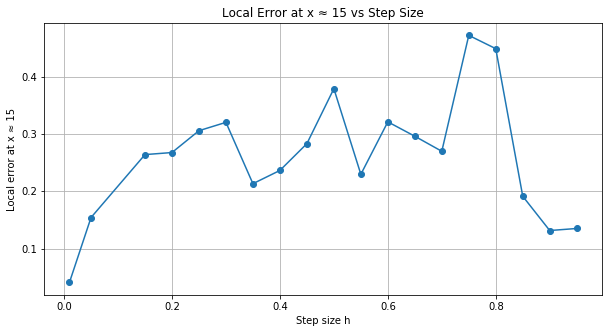

In [9]:
#Plot of local errors at x = 15 vs h values

plt.figure(figsize=(10, 5))
plt.plot(h_values, local_errors, marker='o')
plt.xlabel('Step size h')
plt.ylabel('Local error at x ≈ 15')
plt.title('Local Error at x ≈ 15 vs Step Size')
plt.grid(True)
plt.show()

Forward Euler approximates the solution reasonably well for small step sizes, but accuracy decreases as h increases. The plot of all solution curves shows that the runs with smaller h, especially h=0.01 and h=0.05, track the exact solution much more closely, while larger step sizes drift away and distort the oscillatory behavior. The average error grows with h because forward Euler is only a first-order method, so each step introduces truncation error that accumulates over the long interval [0,10π]. (Although, average error did drop off as h approached 1. Unfortunately, I don't a reasonable explanation for this). The local error near x≈15 also tends to increase with h, although it may not rise smoothly because different step sizes hit slightly different points near 15. Overall, the experiment shows that smaller step sizes produce more reliable numerical solutions, while larger step sizes sacrifice accuracy for computational expense.

### STABILITY ANALYSIS

### Exact Solution (for insight)

Separate variables:
$$
\frac{1}{y}dy = -2\cos(x)\,dx.
$$

Integrate:
$$
\ln|y| = -2\sin(x) + C.
$$

Exponentiate:
$$
y(x) = Ce^{-2\sin(x)}.
$$

Apply $ y(0) = y_0 $:
$$
y(x) = y_0 e^{-2\sin(x)}.
$$

Since $ \sin(x) \in [-1,1] $, we have:
$$
e^{-2} \le e^{-2\sin(x)} \le e^2,
$$

so the solution is bounded:
$$
|y_0|e^{-2} \le |y(x)| \le |y_0|e^2.
$$

---

###  Forward Euler Method

Forward Euler gives:
$$
y_{n+1} = y_n + h f(x_n, y_n).
$$

Here, $f(x,y) = -2y\cos(x)$, so:
$$
y_{n+1} = y_n + h(-2y_n\cos(x_n)) = (1 - 2h\cos(x_n))y_n.
$$

The amplification factor is:
$$
G_n = 1 - 2h\cos(x_n).
$$

---

### 4. Stability Condition

Using the linear test equation $ y' = \lambda y $, forward Euler is stable when:
$$
|1 + h\lambda| < 1.
$$

Here, $$ \lambda(x_n) = -2\cos(x_n) $$, so:
$$
|1 - 2h\cos(x_n)| < 1.
$$

Solve:
$$
-1 < 1 - 2h\cos(x_n) < 1
$$

$$
-2 < -2h\cos(x_n) < 0
$$

$$
2 > 2h\cos(x_n) > 0
$$

$$
0 < h\cos(x_n) < 1.
$$

---

### 5. Interpretation

When $ \cos(x_n) > 0 $, the equation behaves like a decaying system, and stability requires $0 < h < \frac{1}{\cos(x_n)}.$

- Worst case: $ \cos(x_n) = 1 $, giving:
  $$
  0 < h < 1.
  $$

- When $ \cos(x_n) = 0$:
  $$
  G_n = 1 - h*0 = 1 \quad \text{(neutral stability)}.
  $$


---

### 6. Conclusion

- The effective parameter is:
  $$
  \lambda(x) = -2\cos(x).
  $$

- The forward Euler update is:
  $$
  y_{n+1} = (1 - 2h\cos(x_n))y_n.
  $$

- Local stability condition:
  $$
  |1 - 2h\cos(x_n)| < 1.
  $$

- Because $ \cos(x) $ changes sign, no single global $h$ ensures stability everywhere.

- However, in regions where the system is decaying, the restrictive condition is:
  $$
  0 < h < 1.
  $$

- The exact solution remains bounded:
  $$
  |y_0|e^{-2} \le |y(x)| \le |y_0|e^2,
  $$
  so instability is purely **numerical**, not from the differential equation itself.